In [1]:
import matplotlib.pyplot as plt
import pandas as pd

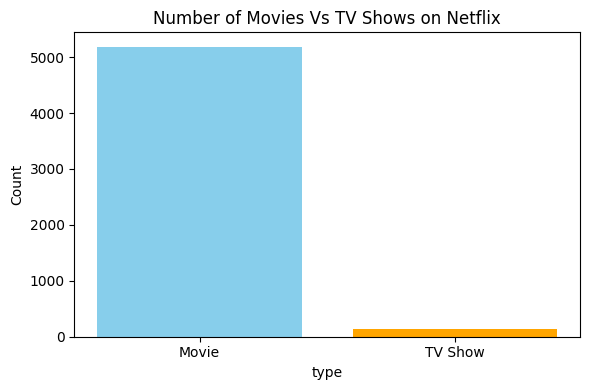

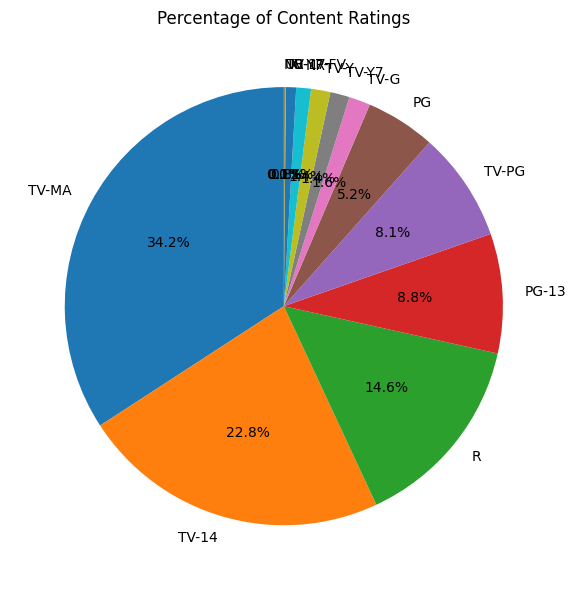

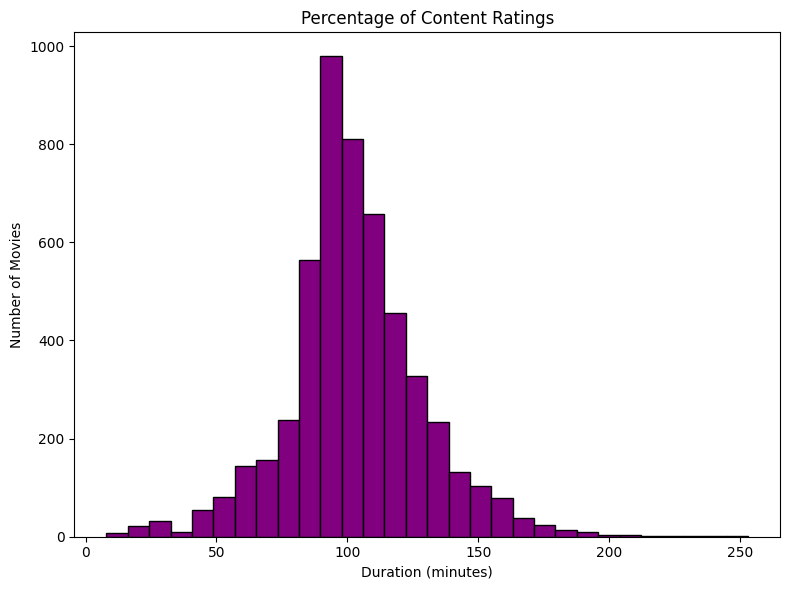

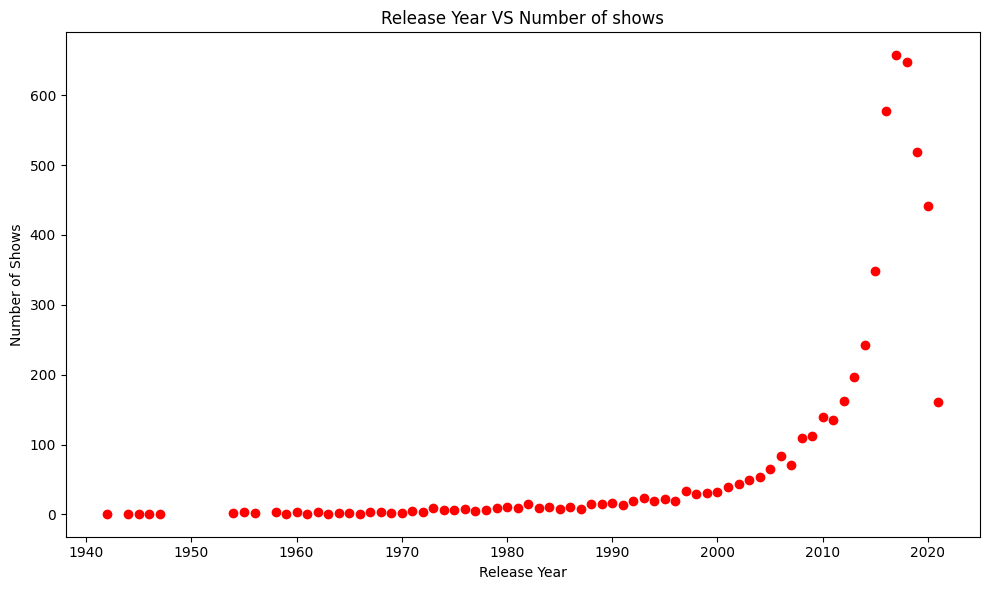

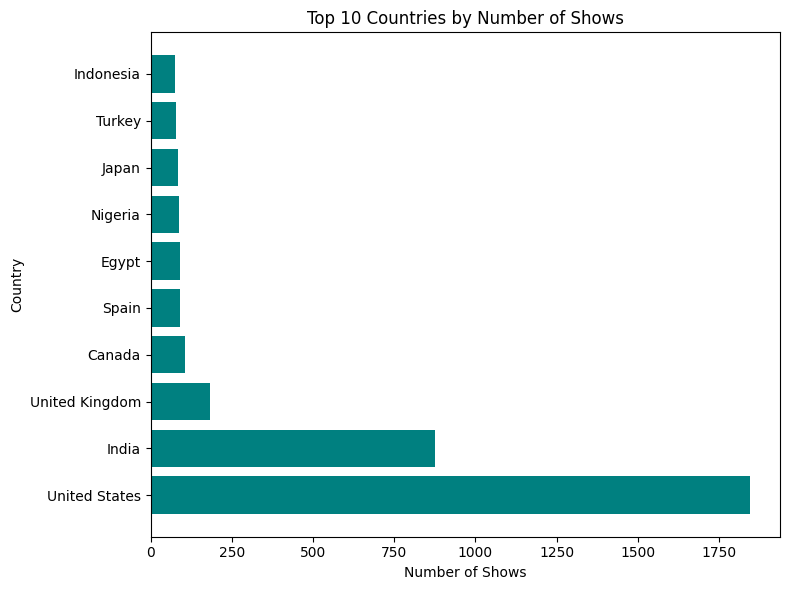

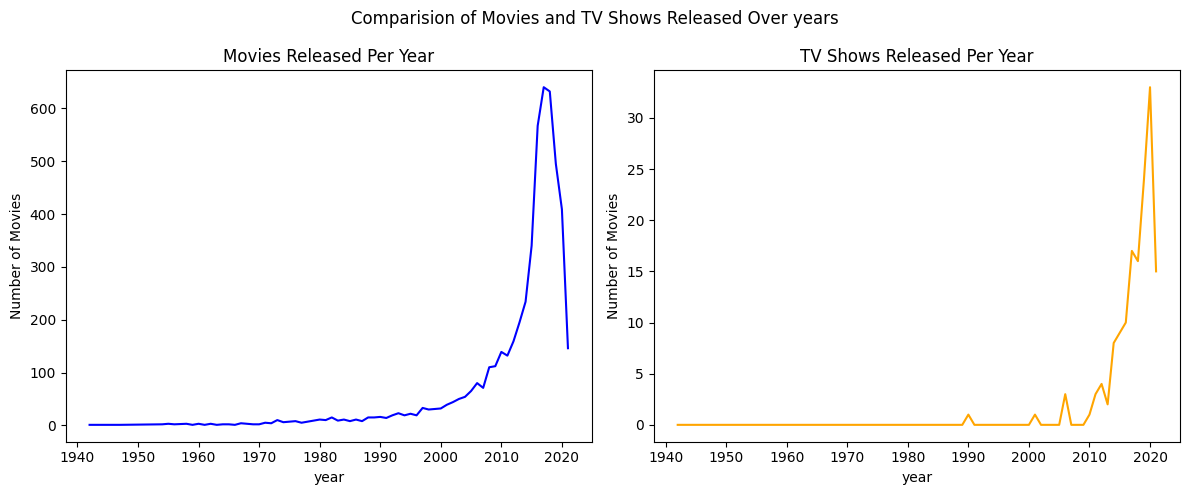

In [36]:
df = pd.read_csv("Netflix_Dataset.csv")

df = df.dropna(subset=['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration'])

type_counts = df["type"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index , type_counts.values , color=['skyblue' ,'orange'])
plt.title("Number of Movies Vs TV Shows on Netflix")
plt.xlabel("type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('Movies_vs_Tvshows.png')
plt.show()


ragting_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(ragting_counts , labels=ragting_counts.index , autopct='%1.1f%%',startangle=90)
plt.title("Percentage of Content Ratings")
plt.tight_layout()
plt.savefig("Content Ratings.png")
plt.show()


movie_df = df[df["type"] == "Movie"].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min','').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'] , bins=30 ,color='purple' , edgecolor='black')
plt.title("Percentage of Content Ratings")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("Movie-Duration-histogram.png")
plt.show()

relese_counts = df["release_year"].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(relese_counts.index , relese_counts.values , color='red')
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")
plt.title("Release Year VS Number of shows")
plt.tight_layout()
plt.savefig("Release-year-Scatter.png")
plt.show()


country_counts = df["country"].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index , country_counts.values , color='teal')
plt.title("Top 10 Countries by Number of Shows")
plt.xlabel("Number of Shows")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()



content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig , ax = plt.subplots(1 ,2, figsize=(12,5))

# 1st subplot : Movies (OOA)
ax[0].plot(content_by_year.index , content_by_year['Movie'] , color='blue')
ax[0].set_title("Movies Released Per Year")
ax[0].set_xlabel("year")
ax[0].set_ylabel("Number of Movies")

#  2nd subplot : Tv Shows (OOA)

ax[1].plot(content_by_year.index , content_by_year['TV Show' \
''] , color='orange')
ax[1].set_title("TV Shows Released Per Year")
ax[1].set_xlabel("year")
ax[1].set_ylabel("Number of Movies")

fig.suptitle("Comparision of Movies and TV Shows Released Over years")

plt.tight_layout()
plt.savefig("Movies-tv-shows-comparison.png")
plt.show()